# **INITIALISING THE ENVIRONMENT**


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
accuracy_score, confusion_matrix, classification_report,
mean_absolute_error, mean_squared_error, r2_score
)
from sklearn.datasets import fetch_california_housing, load_iris, load_diabetes, load_breast_cancer
print("Environment ready.")

Environment ready.


# *Loading the dataset*

In [2]:
import os

# See the datasets/files available to your notebook
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))


/kaggle/input/datasets/ahmedjoiya/winequality-lab-1/winequality-red.csv
/kaggle/input/datasets/ahmedjoiya/diabetes/diabetes
/kaggle/input/datasets/imtkaggleteam/diabetes/diabetes.csv


In [3]:
import pandas as pd

wine_url = "/kaggle/input/datasets/ahmedjoiya/winequality-lab-1/winequality-red.csv"

wine_df = pd.read_csv(wine_url, sep=";")

display(wine_df.head())

print("Shape:", wine_df.shape)

print("\nData types:")
print(wine_df.dtypes)

print("\nMissing values:")
print(wine_df.isnull().sum())

print("\nSummary:")
display(wine_df.describe())


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


Shape: (1599, 12)

Data types:
fixed acidity           float64
volatile acidity        float64
citric acid             float64
residual sugar          float64
chlorides               float64
free sulfur dioxide     float64
total sulfur dioxide    float64
density                 float64
pH                      float64
sulphates               float64
alcohol                 float64
quality                   int64
dtype: object

Missing values:
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

Summary:


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


# *Visualize the Target*

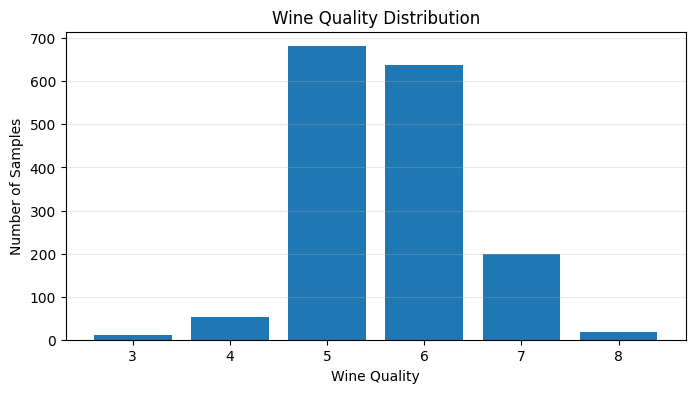

In [4]:
quality_counts = wine_df["quality"].value_counts().sort_index()
plt.figure(figsize=(8,4))
plt.bar(quality_counts.index, quality_counts.values)
plt.xlabel("Wine Quality")
plt.ylabel("Number of Samples")
plt.title("Wine Quality Distribution")
plt.grid(axis="y", alpha=0.3)
plt.show()

# Preprocessing

Median

In [5]:
# Preprocessing using Median

from sklearn.impute import SimpleImputer
import pandas as pd

# Separate features and target
X = wine_df.drop("quality", axis=1)
y = wine_df["quality"]

# Fill missing values with median
imputer_median = SimpleImputer(strategy="median")

X_median = pd.DataFrame(
    imputer_median.fit_transform(X),
    columns=X.columns
)

# Combine with target
wine_median = pd.concat(
    [X_median, y.reset_index(drop=True)],
    axis=1
)

print("Missing values after median imputation:")
print(wine_median.isnull().sum())

display(wine_median.head())


Missing values after median imputation:
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


mode

In [6]:
# Mode Imputation

from sklearn.impute import SimpleImputer

# Select numerical columns except target
X = wine_df.drop("quality", axis=1)
y = wine_df["quality"]

# Apply mode imputation
mode_imputer = SimpleImputer(strategy="most_frequent")
X_mode = pd.DataFrame(
    mode_imputer.fit_transform(X),
    columns=X.columns
)

# Add quality column
wine_mode = pd.concat(
    [X_mode, y.reset_index(drop=True)],
    axis=1
)

print("Missing values after mode imputation:")
print(wine_mode.isnull().sum())

display(wine_mode.head())


Missing values after mode imputation:
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


# *Spliting the data*

In [7]:
X_wine = wine_df.drop(columns=["quality"])
y_wine = (wine_df["quality"] >= 6).astype(int)
X_train, X_test, y_train, y_test = train_test_split(
X_wine, y_wine,
test_size=0.20,
random_state=42,
stratify=y_wine
)
print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 1279
Testing samples: 320


# KNN WITHOUT Scaling

In [8]:
knn_unscaled = KNeighborsClassifier(n_neighbors=5)
knn_unscaled.fit(X_train, y_train)
y_pred_unscaled = knn_unscaled.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred_unscaled))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_unscaled))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_unscaled))

Accuracy: 0.634375

Confusion Matrix:
[[104  45]
 [ 72  99]]

Classification Report:
              precision    recall  f1-score   support

           0       0.59      0.70      0.64       149
           1       0.69      0.58      0.63       171

    accuracy                           0.63       320
   macro avg       0.64      0.64      0.63       320
weighted avg       0.64      0.63      0.63       320



# KNN With Feature Scaling

In [9]:
scaler = StandardScaler()
# Learn scaling parameters from TRAINING data only
X_train_scaled = scaler.fit_transform(X_train)
# Apply the same parameters to TEST data
X_test_scaled = scaler.transform(X_test)
knn_scaled = KNeighborsClassifier(n_neighbors=5)
knn_scaled.fit(X_train_scaled, y_train)
y_pred_scaled = knn_scaled.predict(X_test_scaled)
print("Unscaled accuracy:", accuracy_score(y_test, y_pred_unscaled))
print("Scaled accuracy: ", accuracy_score(y_test, y_pred_scaled))

Unscaled accuracy: 0.634375
Scaled accuracy:  0.740625


# Experiment with K

,K,Accuracy
0,2,0.712500
1,4,0.715625
2,6,0.750000
3,8,0.753125
4,10,0.765625
5,12,0.753125
6,16,0.765625
7,20,0.753125


Best K on this test split: 10


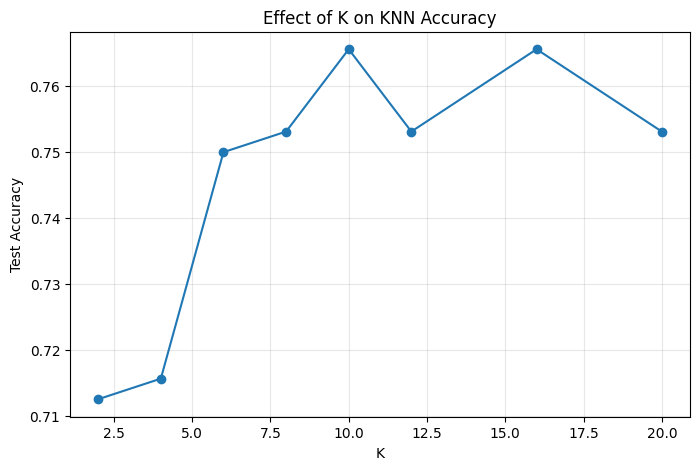

In [10]:
k_values = [2, 4, 6, 8, 10, 12, 16, 20]
k_results = []

for k in k_values:
  model = KNeighborsClassifier(n_neighbors=k)
  model.fit(X_train_scaled, y_train)
  pred = model.predict(X_test_scaled)
  acc = accuracy_score(y_test, pred)
  k_results.append([k, acc])
k_results_df = pd.DataFrame(k_results, columns=["K", "Accuracy"])
display(k_results_df)
best_row = k_results_df.loc[k_results_df["Accuracy"].idxmax()]
print("Best K on this test split:", int(best_row["K"]))
plt.figure(figsize=(8,5))
plt.plot(k_results_df["K"], k_results_df["Accuracy"], marker="o")
plt.xlabel("K")
plt.ylabel("Test Accuracy")
plt.title("Effect of K on KNN Accuracy")
plt.grid(True, alpha=0.3)
plt.show()

# Predict a New Wine

In [11]:
best_k = int(best_row["K"])
final_knn = KNeighborsClassifier(n_neighbors=best_k)
final_knn.fit(X_train_scaled, y_train)
new_wine = pd.DataFrame([{
"fixed acidity": 7.4,
"volatile acidity": 0.70,
"citric acid": 0.00,
"residual sugar": 1.9,
"chlorides": 0.076,
"free sulfur dioxide": 11.0,
"total sulfur dioxide": 34.0,
"density": 0.9978,
"pH": 3.51,
"sulphates": 0.56,
"alcohol": 9.4
}])
new_wine_scaled = scaler.transform(new_wine)
prediction = final_knn.predict(new_wine_scaled)[0]
print("Predicted class:", "GOOD WINE" if prediction == 1 else "NOT GOOD WINE")

Predicted class: NOT GOOD WINE


# Linear Regression on Wine Quality

In [12]:
X_reg = wine_df.drop(columns=["quality"])
y_reg = wine_df["quality"]
Xr_train, Xr_test, yr_train, yr_test = train_test_split(
X_reg, y_reg, test_size=0.20, random_state=42
)
wine_reg = LinearRegression()
wine_reg.fit(Xr_train, yr_train)
yr_pred = wine_reg.predict(Xr_test)
mae = mean_absolute_error(yr_test, yr_pred)
mse = mean_squared_error(yr_test, yr_pred)
rmse = np.sqrt(mse)
r2 = r2_score(yr_test, yr_pred)
print("MAE :", round(mae,4))
print("MSE :", round(mse,4))
print("RMSE:", round(rmse,4))
print("R2 :", round(r2,4))

MAE : 0.5035
MSE : 0.39
RMSE: 0.6245
R2 : 0.4032


# Interpret Regression Metrics

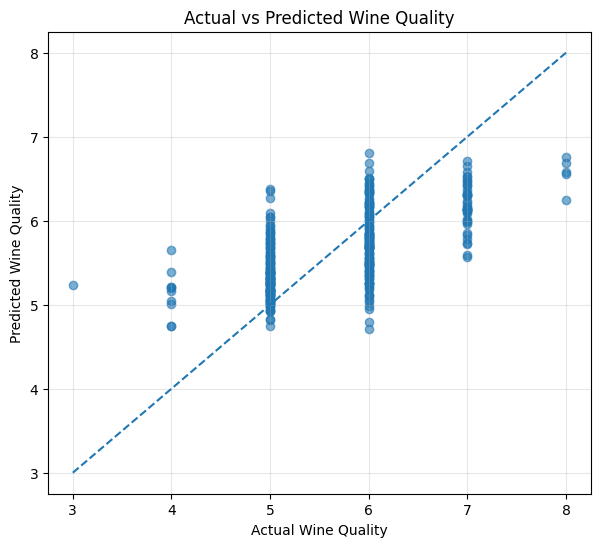

In [13]:
plt.figure(figsize=(7,6))
plt.scatter(yr_test, yr_pred, alpha=0.6)
minimum = min(yr_test.min(), yr_pred.min())
maximum = max(yr_test.max(), yr_pred.max())
plt.plot([minimum, maximum], [minimum, maximum], linestyle="--")
plt.xlabel("Actual Wine Quality")
plt.ylabel("Predicted Wine Quality")
plt.title("Actual vs Predicted Wine Quality")
plt.grid(True, alpha=0.3)
plt.show()

# #Additional Dataset Check 

In [14]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# ============================================================
# 1. Load dataset
# ============================================================

diab_url = "/kaggle/input/datasets/imtkaggleteam/diabetes/diabetes.csv"

df = pd.read_csv(diab_url)

print("Original shape:", df.shape)


# ============================================================
# 2. Convert numeric columns to numeric
# ============================================================

numeric_cols = [
    "id", "chol", "stab.glu", "hdl", "ratio", "glyhb",
    "age", "height", "weight", "bp.1s", "bp.1d",
    "bp.2s", "bp.2d", "waist", "hip", "time.ppn"
]

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")


# ============================================================
# 3. Create target
# ============================================================

# glyhb < 6.5  = 0
# glyhb >= 6.5 = 1

df["glyhb_class"] = (df["glyhb"] >= 6.5).astype(int)


# ============================================================
# 4. Select features
# ============================================================

feature_cols = [
    "chol",
    "stab.glu",
    "hdl",
    "ratio",
    "age",
    "height",
    "weight",
    "bp.1s",
    "bp.1d",
    "bp.2s",
    "bp.2d",
    "waist",
    "hip",
    "time.ppn"
]


# ============================================================
# 5. WITHOUT MISSING-VALUE IMPUTATION
# ============================================================

df_without = df.dropna(
    subset=feature_cols + ["glyhb_class"]
)

X_without = df_without[feature_cols]
y_without = df_without["glyhb_class"]

X_train, X_test, y_train, y_test = train_test_split(
    X_without,
    y_without,
    test_size=0.20,
    random_state=42,
    stratify=y_without
)

# Scaling
scaler_without = StandardScaler()

X_train_scaled = scaler_without.fit_transform(X_train)
X_test_scaled = scaler_without.transform(X_test)

# KNN
knn_without = KNeighborsClassifier(n_neighbors=5)

knn_without.fit(X_train_scaled, y_train)

y_pred_without = knn_without.predict(X_test_scaled)

accuracy_without = accuracy_score(
    y_test,
    y_pred_without
)

print("\n====================================")
print("WITHOUT MISSING-VALUE IMPUTATION")
print("====================================")
print("Samples:", len(df_without))
print("Accuracy:", round(accuracy_without, 4))


# ============================================================
# 6. WITH MISSING-VALUE IMPUTATION
# ============================================================

df_with = df.copy()

# Numerical columns -> Median
for col in feature_cols:
    df_with[col] = df_with[col].fillna(
        df_with[col].median()
    )

X_with = df_with[feature_cols]
y_with = df_with["glyhb_class"]

X_train, X_test, y_train, y_test = train_test_split(
    X_with,
    y_with,
    test_size=0.20,
    random_state=42,
    stratify=y_with
)

# Scaling
scaler_with = StandardScaler()

X_train_scaled = scaler_with.fit_transform(X_train)
X_test_scaled = scaler_with.transform(X_test)

# KNN
knn_with = KNeighborsClassifier(n_neighbors=5)

knn_with.fit(X_train_scaled, y_train)

y_pred_with = knn_with.predict(X_test_scaled)

accuracy_with = accuracy_score(
    y_test,
    y_pred_with
)

print("\n====================================")
print("WITH MISSING-VALUE IMPUTATION")
print("====================================")
print("Samples:", len(df_with))
print("Accuracy:", round(accuracy_with, 4))


# ============================================================
# 7. FINAL COMPARISON
# ============================================================

print("\n====================================")
print("FINAL ACCURACY COMPARISON")
print("====================================")

print(
    "Without missing-value imputation:",
    round(accuracy_without, 4)
)

print(
    "With median imputation:",
    round(accuracy_with, 4)
)


Original shape: (403, 19)

WITHOUT MISSING-VALUE IMPUTATION
Samples: 139
Accuracy: 0.8571

WITH MISSING-VALUE IMPUTATION
Samples: 403
Accuracy: 0.8889

FINAL ACCURACY COMPARISON
Without missing-value imputation: 0.8571
With median imputation: 0.8889


## Task 1 — Dataset Preparation

 1. **Why use `sep=";"`?** — Because the Wine dataset columns are separated by semicolons.
2. **Why separate X and y?** — X contains input features, while y contains the target.
3. **Why make y binary?** — To classify wines into good (`1`) and lower quality (`0`).
4. **Why use stratification?** — To keep the same class ratio in train and test data.
5. **Why use `random_state=42`?** — To get the same split every time.

 ## Task 2 — KNN

 1. **Why scale KNN data?** — KNN uses distances, so features should have similar scales.
2. **What does StandardScaler do?** — It standardizes features to a common scale.
3. **Why fit scaler only on training data?** — To avoid data leakage from the test set.
4. **What is K in KNN?** — K is the number of nearest neighbors used for prediction.
5. **What if K is too small?** — The model may overfit.
6. **What if K is too large?** — The model may underfit.
7. **Why is K not universal?** — Different datasets need different K values.
8. **What is a confusion matrix?** — It shows correct and incorrect predictions for each class.
9. **What is a classification report?** — It shows precision, recall, F1-score, and support.

 ## Task 3 — Prediction and Regression

 1. **Why use the same 11 features?** — The model was trained using those exact features.
2. **Why keep the same feature order?** — Each column represents a specific feature.
3. **Why use the same scaler?** — The new data must be transformed like the training data.
4. **What is classification?** — Predicting categories such as 0 or 1.
5. **What is regression?** — Predicting a numerical value such as wine quality.
6. **What is MAE?** — It measures the average absolute prediction error.
7. **What is MSE?** — It measures the average squared prediction error.
8. **What is RMSE?** — It is the square root of MSE.
9. **What is R²?** — It shows how well the model explains the target variation.
10. **Why use a diagonal line?** — It represents perfect predictions.

 ## Task 4 — New Dataset

 1. **Why use another dataset?** — To test whether the workflow works on different data.
2. **Why can Iris behave differently from Wine?** — Iris has different features, size, and class patterns.
3. **Why scale Iris for KNN?** — KNN depends on feature distances.
4. **Why test different K values?** — To find how K affects model accuracy.
5. **Why compare Iris and Wine?** — Different datasets can produce different model performance.